# Welch Two-Sample T-Test: Gender and Height

## Project Cycle 3

This notebook performs the main statistical inference for the selected research question:

**Is the mean height different between male and female students?**

中文研究問題：

**男性與女性學生的平均身高是否不同？**

---

## Variables Used

- Group variable: `Sex`
- Response variable: `Height_m`

---

## Statistical Method

Because height is a quantitative variable, this project compares the mean height between two independent groups.

The method used in this notebook is:

**Welch two-sample t-test**

Welch t-test is used because it does not assume equal variances between the two groups.

---

## Hypotheses

Null hypothesis:

**H₀: μ_male − μ_female = 0**

Alternative hypothesis:

**H₁: μ_male − μ_female ≠ 0**

---

## Significance Level

- α = 0.05

讀取資料： C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\data\data processed\YRBS_2007_cleaned_gender_height.csv
輸出資料夾： C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\outputs
資料筆數與欄位數： (13062, 4)


,WhatIsYourSex,Sex,HowTallAreYouWithoutShoesInMeters,Height_m
0,2,Male,1.70,1.70
1,1,Female,1.63,1.63
2,1,Female,1.73,1.73
3,1,Female,1.78,1.78
4,1,Female,1.60,1.60


可用資料筆數： 13062
Sex
Male      6572
Female    6490
Name: count, dtype: int64
Male 樣本數： 6572
Female 樣本數： 6490
Male 平均身高： 1.757364576993305
Female 平均身高： 1.62991063174114
群體摘要表：


,Group,n,Mean_Height_m,SD_Height_m,Mean_Height_cm,SD_Height_cm
0,Female,6490,1.6299,0.0738,162.9911,7.3767
1,Male,6572,1.7574,0.0838,175.7365,8.3771


群體摘要表已輸出到：
C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\outputs\tables\gender_height_group_summary.csv
Welch two-sample t-test 結果：
t statistic: 92.3128644005698
df: 12892.353675627497
p-value: 0.0
Mean difference, Male - Female: 0.12745394525216502
95% CI: 0.12474762042444928 to 0.13016027007988076
Welch t-test 結果表：


,Method,Mean_Difference_Male_minus_Female_m,Mean_Difference_Male_minus_Female_cm,t_statistic,df,p_value,CI_95_Lower_m,CI_95_Upper_m,CI_95_Lower_cm,CI_95_Upper_cm,Alpha
0,Welch two-sample t-test,0.127454,12.745395,92.312864,12892.353676,0.0,0.124748,0.13016,12.474762,13.016027,0.05


Welch t-test 結果表已輸出到：
C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\outputs\tables\gender_height_welch_test_results.csv


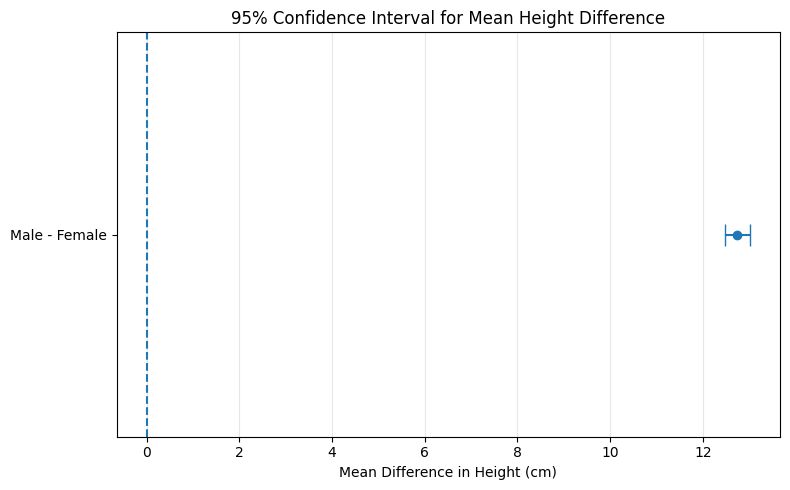

信賴區間圖已輸出到：
C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\outputs\figures\gender_height_ci_plot.png

Welch Two-Sample T-Test Interpretation

Research question:
Is the mean height different between male and female students?

The cleaned dataset includes 6490 female students and 6572 male students.

Female mean height: 162.99 cm
Male mean height: 175.74 cm

The estimated mean difference, Male - Female, is 12.75 cm.
The 95% confidence interval for the difference is from 12.47 cm to 13.02 cm.

Welch two-sample t-test result:
t = 92.3129
df = 12892.3537
p-value = 0.000000

At alpha = 0.05, we reject the null hypothesis.
Therefore, there is a statistically significant difference in mean height between male and female students.

中文解釋：

本研究使用 Welch two-sample t-test 檢定男性與女性學生的平均身高是否不同。

資料中女性學生共有 6490 人，男性學生共有 6572 人。
女性學生的平均身高為 162.99 公分，男性學生的平均身高為 175.74 公分。

男性與女性的平均身高差異為 12.75 公分。
95% 信賴區間為 12.47 公分到 13.02 公分。

檢定結果顯示：
t = 92.3129
df = 12892.3537
p-value = 0.000000

在 α = 0.05 的顯著水準下，我們拒絕

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display

# =========================
# 1. 設定資料路徑
# =========================

processed_dir = Path(r"C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\data\data processed")
output_dir = Path(r"C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\outputs")

input_file = processed_dir / "YRBS_2007_cleaned_gender_height.csv"

tables_dir = output_dir / "tables"
figures_dir = output_dir / "figures"
summary_dir = output_dir / "summary"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
summary_dir.mkdir(parents=True, exist_ok=True)

print("讀取資料：", input_file)
print("輸出資料夾：", output_dir)

# =========================
# 2. 讀取清理後資料
# =========================

df = pd.read_csv(input_file)

print("資料筆數與欄位數：", df.shape)
display(df.head())

# =========================
# 3. 保留需要的欄位
# =========================

required_columns = ["Sex", "Height_m"]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"資料中缺少必要欄位：{col}")

df = df[required_columns].copy()
df = df.dropna(subset=["Sex", "Height_m"])

df = df[df["Sex"].isin(["Female", "Male"])].copy()
df["Height_m"] = pd.to_numeric(df["Height_m"], errors="coerce")
df = df.dropna(subset=["Height_m"])

print("可用資料筆數：", df.shape[0])
print(df["Sex"].value_counts())

# =========================
# 4. 分成 Male 與 Female 兩組
# =========================

male_height = df.loc[df["Sex"] == "Male", "Height_m"]
female_height = df.loc[df["Sex"] == "Female", "Height_m"]

n_male = male_height.count()
n_female = female_height.count()

mean_male = male_height.mean()
mean_female = female_height.mean()

sd_male = male_height.std(ddof=1)
sd_female = female_height.std(ddof=1)

print("Male 樣本數：", n_male)
print("Female 樣本數：", n_female)
print("Male 平均身高：", mean_male)
print("Female 平均身高：", mean_female)

# =========================
# 5. 建立群體摘要表
# =========================

group_summary = pd.DataFrame({
    "Group": ["Female", "Male"],
    "n": [n_female, n_male],
    "Mean_Height_m": [mean_female, mean_male],
    "SD_Height_m": [sd_female, sd_male],
    "Mean_Height_cm": [mean_female * 100, mean_male * 100],
    "SD_Height_cm": [sd_female * 100, sd_male * 100]
})

group_summary = group_summary.round(4)

print("群體摘要表：")
display(group_summary)

group_summary_file = tables_dir / "gender_height_group_summary.csv"
group_summary.to_csv(group_summary_file, index=False, encoding="utf-8-sig")

print("群體摘要表已輸出到：")
print(group_summary_file)

# =========================
# 6. Welch two-sample t-test
# =========================

t_stat, p_value = stats.ttest_ind(
    male_height,
    female_height,
    equal_var=False
)

# 平均差異：Male - Female
mean_difference = mean_male - mean_female

# Welch 標準誤
se_difference = np.sqrt((sd_male**2 / n_male) + (sd_female**2 / n_female))

# Welch 自由度
df_welch = ((sd_male**2 / n_male) + (sd_female**2 / n_female))**2 / (
    ((sd_male**2 / n_male)**2 / (n_male - 1)) +
    ((sd_female**2 / n_female)**2 / (n_female - 1))
)

# 95% 信賴區間
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha / 2, df_welch)

ci_lower = mean_difference - t_critical * se_difference
ci_upper = mean_difference + t_critical * se_difference

print("Welch two-sample t-test 結果：")
print("t statistic:", t_stat)
print("df:", df_welch)
print("p-value:", p_value)
print("Mean difference, Male - Female:", mean_difference)
print("95% CI:", ci_lower, "to", ci_upper)

# =========================
# 7. 建立檢定結果表
# =========================

test_results = pd.DataFrame({
    "Method": ["Welch two-sample t-test"],
    "Mean_Difference_Male_minus_Female_m": [mean_difference],
    "Mean_Difference_Male_minus_Female_cm": [mean_difference * 100],
    "t_statistic": [t_stat],
    "df": [df_welch],
    "p_value": [p_value],
    "CI_95_Lower_m": [ci_lower],
    "CI_95_Upper_m": [ci_upper],
    "CI_95_Lower_cm": [ci_lower * 100],
    "CI_95_Upper_cm": [ci_upper * 100],
    "Alpha": [alpha]
})

test_results = test_results.round(6)

print("Welch t-test 結果表：")
display(test_results)

test_results_file = tables_dir / "gender_height_welch_test_results.csv"
test_results.to_csv(test_results_file, index=False, encoding="utf-8-sig")

print("Welch t-test 結果表已輸出到：")
print(test_results_file)

# =========================
# 8. 畫平均差異 95% 信賴區間圖
# =========================

plt.figure(figsize=(8, 5))

plt.errorbar(
    x=[mean_difference * 100],
    y=[1],
    xerr=[[((mean_difference - ci_lower) * 100)], [((ci_upper - mean_difference) * 100)]],
    fmt="o",
    capsize=8
)

plt.axvline(0, linestyle="--")
plt.yticks([1], ["Male - Female"])
plt.xlabel("Mean Difference in Height (cm)")
plt.title("95% Confidence Interval for Mean Height Difference")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

ci_plot_file = figures_dir / "gender_height_ci_plot.png"
plt.savefig(ci_plot_file, dpi=300, bbox_inches="tight")
plt.show()

print("信賴區間圖已輸出到：")
print(ci_plot_file)

# =========================
# 9. 自動產生文字結論
# =========================

female_mean_cm = mean_female * 100
male_mean_cm = mean_male * 100
difference_cm = mean_difference * 100
ci_lower_cm = ci_lower * 100
ci_upper_cm = ci_upper * 100

if p_value < alpha:
    decision = "reject the null hypothesis"
    chinese_decision = "拒絕虛無假設"
    conclusion = "there is a statistically significant difference in mean height between male and female students"
    chinese_conclusion = "男性與女性學生的平均身高存在統計上顯著差異"
else:
    decision = "fail to reject the null hypothesis"
    chinese_decision = "無法拒絕虛無假設"
    conclusion = "there is not enough evidence to conclude that mean height differs between male and female students"
    chinese_conclusion = "沒有足夠證據顯示男性與女性學生的平均身高存在統計上顯著差異"

interpretation_text = f"""
Welch Two-Sample T-Test Interpretation

Research question:
Is the mean height different between male and female students?

The cleaned dataset includes {n_female} female students and {n_male} male students.

Female mean height: {female_mean_cm:.2f} cm
Male mean height: {male_mean_cm:.2f} cm

The estimated mean difference, Male - Female, is {difference_cm:.2f} cm.
The 95% confidence interval for the difference is from {ci_lower_cm:.2f} cm to {ci_upper_cm:.2f} cm.

Welch two-sample t-test result:
t = {t_stat:.4f}
df = {df_welch:.4f}
p-value = {p_value:.6f}

At alpha = 0.05, we {decision}.
Therefore, {conclusion}.

中文解釋：

本研究使用 Welch two-sample t-test 檢定男性與女性學生的平均身高是否不同。

資料中女性學生共有 {n_female} 人，男性學生共有 {n_male} 人。
女性學生的平均身高為 {female_mean_cm:.2f} 公分，男性學生的平均身高為 {male_mean_cm:.2f} 公分。

男性與女性的平均身高差異為 {difference_cm:.2f} 公分。
95% 信賴區間為 {ci_lower_cm:.2f} 公分到 {ci_upper_cm:.2f} 公分。

檢定結果顯示：
t = {t_stat:.4f}
df = {df_welch:.4f}
p-value = {p_value:.6f}

在 α = 0.05 的顯著水準下，我們{chinese_decision}。
因此，{chinese_conclusion}。
"""

print(interpretation_text)

interpretation_file = summary_dir / "gender_height_welch_interpretation.txt"

with open(interpretation_file, "w", encoding="utf-8") as f:
    f.write(interpretation_text)

print("文字結論已輸出到：")
print(interpretation_file)